<a href="https://colab.research.google.com/github/namithatholasi/undergrad_ml_assignments/blob/main/Demand_Estimation_Lab_Notebook1_DataAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Demand Estimation and Market Analysis: Air Fryers

# Names/Computing IDS: Clairice Lou (pnu9pt), Namitha Tholasi (cku5zp), Ngan Huynh (dfe4yx), Yannely Escalante Ruiz (usw5zk)

In this lab, you will study the market for air fryers using brand-year data aggregated from Amazon purchases. The goal is to move from descriptive analysis to a simple demand model, and then use that model to infer markups and unit costs.

Use the cleaned file:

```python
air_fryers_clean_brand_year.csv
```

This file keeps the top 10 air-fryer brands from 2019-2023 and drops the long tail of very small brands. The variable `brand_share` has already been recomputed within this cleaned name-brand market, so shares sum to 1 within each year.

## Data

Each row is one brand in one year.

Important columns:

- `year`: calendar year
- `brand`: air-fryer brand
- `purchase_count`: number of purchases by that brand in that year
- `product_count`: number of distinct products observed for that brand-year
- `avg_price`: average price for that brand-year
- `avg_rating`: average review rating for that brand-year
- `brand_share`: purchase share within the cleaned air-fryer market in that year
- `log_brand_share`: `np.log(brand_share)`, already computed for convenience
- `compact_share`, `dual_basket_share`, `oven_style_share`, `rotisserie_share`, `window_share`: product characteristic shares for the brand-year

The original lecture wrote the demand equation using an outside option:

$$
\log(s_{bt}) - \log(s_{ot}).
$$

For this cleaned dataset, we dropped the nuisance long-tail brands instead of treating them as an outside option. You should therefore use:

$$
y_{bt} = \log(s_{bt})
$$

as the outcome and include **year dummies**. The year dummies absorb the year-specific denominator of the multinomial logit share equation. This keeps the assignment focused on the cleaned name-brand market.

## Results Expectations! (Final Part)

Submit a GitHub repo containing:

1. A notebook corresponding to the data analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
2. A notebook corresponding to the data scientist work, including the code and graphs, explicitly answering the questions above in text markdown chunks
3. A notebook corresponding to the pricing analyst work, including the code and graphs, explicitly answering the questions above in text markdown chunks
4. A short presentation of your findings, about 5-8 slides.

Your presentation should be written as if you were giving market intelligence to a business audience. It should include:

- A short description of the air-fryer market
- A few plots showing prices, ratings, and market shares over time
- A short explanation of the demand model (multinomial logistic regression, estimated by linear regression on log market share)
- The estimated price coefficient and why its sign matters
- A discussion of the most important product features
- Estimated unit costs, markups, and share-weighted profits
- A conclusion about the brands' relative positions in the market

Do not fill slides with raw code. Use your code to produce clear tables and figures, then explain the market story in words.

## 1. Data Analysis

Load `air_fryers_clean_brand_year.csv`.

1. Verify that the data contain 10 brands and the years 2019-2023.
2. Plot the following over time by brand:
   - average price
   - average rating
   - brand market share
3. Summarize the product characteristics:
   - Which features are common?
   - Which features are rare?
   - Are there brands that seem to specialize in different product types?
4. Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?

This part of the work is the **data analyst** role: making the data trustworthy, visual, and interpretable before building a model.

In [1]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 147 (delta 6), reused 0 (delta 0), pack-reused 137 (from 3)
Receiving objects: 100% (147/147), 12.78 MiB | 9.29 MiB/s, done.
Resolving deltas: 100% (52/52), done.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./undergrad_ml_assignments/demand_est_project/air_fryers_clean_brand_year.csv')
df.head(10)

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364
5,air_fryers,2019,instant_pot,238,13,78.019945,4.364286,0.542017,0.0,0.550420,0.000000,0.000000,15076,0.015787,-4.148589
6,air_fryers,2019,ninja,2904,18,112.158374,4.778650,0.994490,0.0,0.000000,0.000000,0.000000,15076,0.192624,-1.647015
7,air_fryers,2019,nuwave,484,15,151.099937,4.321901,0.993802,0.0,0.561983,0.111570,0.000000,15076,0.032104,-3.438774
8,air_fryers,2019,oster,506,5,191.943688,4.380830,1.000000,0.0,0.772727,0.000000,0.000000,15076,0.033563,-3.394323
9,air_fryers,2019,ultrean,755,4,80.624675,4.618013,1.000000,0.0,0.835762,0.000000,0.000000,15076,0.050080,-2.994142


### Part 1

In [3]:
num_brands = df['brand'].nunique()
brands = sorted(df['brand'].unique())

num_years = df['year'].nunique()
years = sorted(df['year'].unique())

print(f"Number of brands: {num_brands}")
print(f"Brands: {brands}")
print(f"Number of years: {num_years}")
print(f"Years: {years}")

print("Dataset contains 10 brands for years 2019-2023.")

Number of brands: 10
Brands: ['chefman', 'cosori', 'cuisinart', 'dash', 'gowise usa', 'instant_pot', 'ninja', 'nuwave', 'oster', 'ultrean']
Number of years: 5
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Dataset contains 10 brands for years 2019-2023.


### Part 2

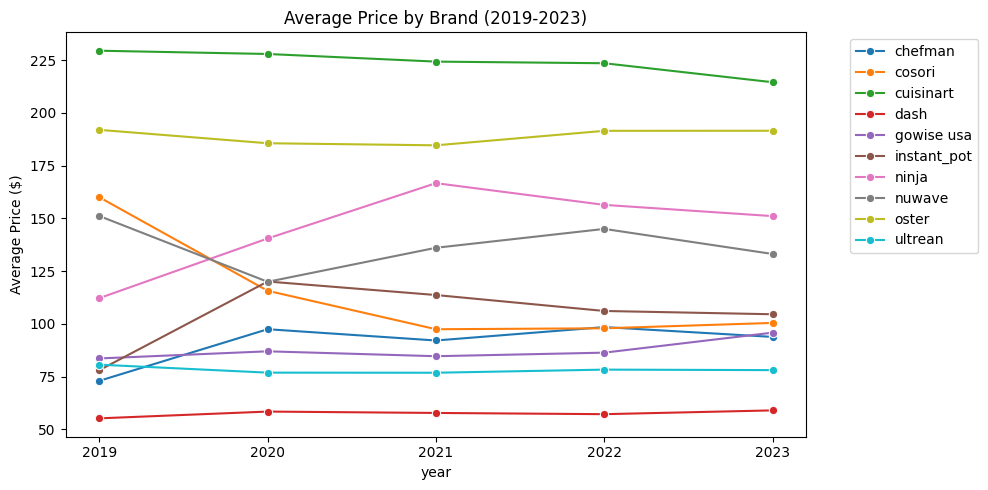

In [11]:
# Average Price
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='year', y='avg_price', hue='brand', marker='o')
plt.title('Average Price by Brand (2019-2023)')
plt.ylabel('Average Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([2019, 2020, 2021, 2022, 2023])
plt.tight_layout()
plt.savefig('air_fryer_price.png')
plt.show()

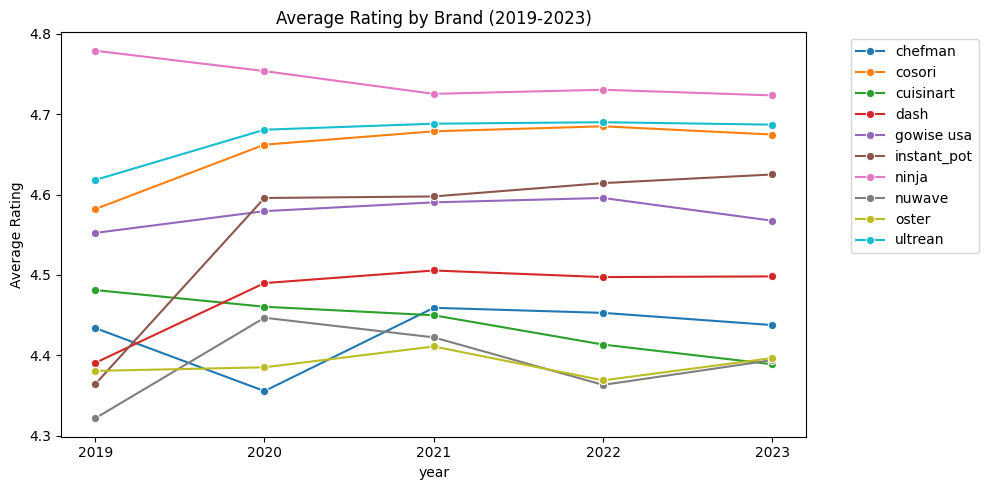

In [12]:
# Average Rating
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='year', y='avg_rating', hue='brand', marker='o')
plt.title('Average Rating by Brand (2019-2023)')
plt.ylabel('Average Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([2019, 2020, 2021, 2022, 2023])
plt.tight_layout()
plt.savefig('air_fryer_rating.png')
plt.show()

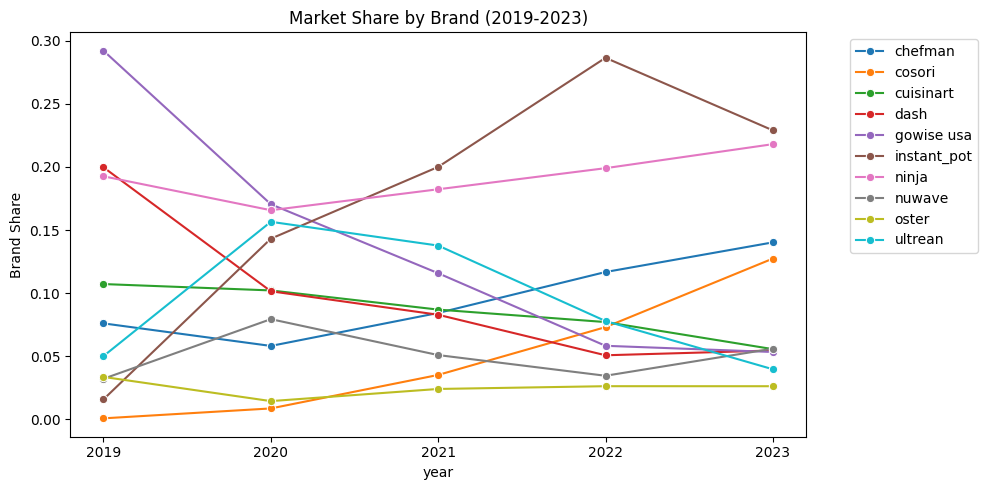

In [13]:
# Market Share
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='year', y='brand_share', hue='brand', marker='o')
plt.title('Market Share by Brand (2019-2023)')
plt.ylabel('Brand Share')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([2019, 2020, 2021, 2022, 2023])
plt.tight_layout()
plt.savefig('air_fryer_share.png')
plt.show()

### Part 3

In [7]:
feature_cols = [
    "compact_share",
    "dual_basket_share",
    "oven_style_share",
    "rotisserie_share",
    "window_share"
]

In [8]:
# Which features are common and which are rare?
market_summary = df[feature_cols].mean().sort_values(ascending=False)
print("Market Wide Feature Prevalence")
print(market_summary)

Market Wide Feature Prevalence
compact_share        0.980081
oven_style_share     0.562647
rotisserie_share     0.070762
window_share         0.036741
dual_basket_share    0.002260
dtype: float64


In [9]:
# Are there brands that specialize in different product types?
brand_summary = df.groupby("brand")[feature_cols].mean()
print("Brand Specialization")
print(brand_summary)

Brand Specialization
             compact_share  dual_basket_share  oven_style_share  \
brand                                                             
chefman           0.961595           0.013462          0.596962   
cosori            0.996784           0.000000          0.029952   
cuisinart         0.995902           0.000000          0.913059   
dash              0.999481           0.000000          0.890098   
gowise usa        0.999877           0.000000          0.183790   
instant_pot       0.859655           0.000030          0.674784   
ninja             0.992084           0.002488          0.100477   
nuwave            0.995431           0.006622          0.542646   
oster             1.000000           0.000000          0.864518   
ultrean           1.000000           0.000000          0.830181   

             rotisserie_share  window_share  
brand                                        
chefman              0.370490      0.363081  
cosori               0.024076      0

**Which features are common?**

The compact feature is by far the most common in the market, making up about 98% of products. This basically means it’s the standard across the industry, like almost every brand offers a compact model. Because of that, just having a compact design probably won’t help a brand stand out or justify a higher price. It’s more like a baseline expectation rather than a special feature, since most companies already include it to stay competitive.

The oven style design makes up about 56.3% of the market, so it’s also pretty common. This means that more than half of air fryers are built like small toaster ovens instead of the classic pull out basket style.
Because it’s already used by a majority of brands, it’s not really a standout feature anymore. It’s more of a popular design choice that many companies rely on rather than something unique or differentiating.

**Which features are rare?**

The rarest feature is the dual basket design, which only appears in about 0.2% of the market. That’s basically close to nonexistent in this dataset, suggesting that multi-zone cooking is still very niche or just starting to emerge.

The window feature is also rare at around 3.7%. Only a small number of brands include a see-through window to monitor cooking.

Rotisserie is a bit more common than the other two, but still relatively niche at about 7.1%. Even though it shows up more often, it’s still far from standard and only appears in a small minority of products.

**Are there brands that seem to specialize in different product types?**

**Chefman** stands out as the most diversified brand, with meaningful shares
across compact (96%), oven-style (60%), rotisserie (37%), and window (36%)
designs. This suggests Chefman intentionally covers multiple product types
rather than focusing on one.

**Cuisinart** and **Dash** lean heavily toward the oven-style format, with
oven-style shares of 91% and 89% respectively, and near-zero rotisserie or
window shares. These brands appear to specialize in the toaster-oven style
of air fryer.

**Cosori** and **Ninja** are almost exclusively compact, with compact shares
above 99% and essentially no oven-style, rotisserie, or window products.
They are the clearest examples of single-format specialization.

**Instant Pot** is the most balanced brand overall, with moderate shares
across compact (86%), oven-style (67%), and some rotisserie (10%),
reflecting its broader kitchen appliance identity.

In general, most brands cluster around the compact format (since it dominates
the market), but brands like Cuisinart and Dash differentiate through
oven-style designs, while Chefman differentiates through rotisserie and
window features.


### Part 4

**Write a short paragraph describing the market. Which brands are expensive? Which brands have large shares? Does the market look stable over time?**

The air fryer market (2019-2023) spans a wide price range. Cuisinart is the
clear premium brand at around 200 dollars, while Dash is the budget option
at around 50 dollars. Ninja and NuWave sit in the mid-to-upper range at
130-190 dollars.

Market share is far from stable. GoWise USA dominated in 2019 (around 29%)
but declined sharply, while Instant Pot surged to around 29% in 2022 before
pulling back. Chefman grew steadily throughout. This churning at the top
suggests an actively competitive market where no single brand has locked in
dominance.